In [7]:
import pandas as pd
import NLProcessing
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import font_manager
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import warnings
from datetime import datetime
date = datetime.today().strftime('%Y%m%d')
warnings.filterwarnings('ignore')
from scipy import stats

# Custom font (optional)
font_path = "fonts"
for f in font_manager.findSystemFonts(fontpaths=[font_path]):
    font_manager.fontManager.addfont(f)
plt.rcParams["font.family"] = "Inter"

In [8]:
import re
from collections import Counter


mbon_csv_path = "MBONlist.csv"
csvfile = pd.read_csv(mbon_csv_path).astype('string')

def rename_labels(mbons, use_mbon_numbers=False):
    """Return list of display labels for MBONs. 
    If use_mbon_numbers=True, converts driver names to MBON numbers.
    If False, returns driver names as-is."""
    if not use_mbon_numbers:
        return list(mbons)
    lobeloc = NLProcessing.generate_lobelocation(mbons, mbon_csv_path)
    raw_labels = []
    for mbon in mbons:
        info = lobeloc[lobeloc['MBON'] == mbon]
        if len(info) > 0:
            raw_number = str(info['MBON_number'].values[0])
            label = raw_number
            raw_labels.append(label if label and label != 'nan' else mbon)
        else:
            raw_labels.append(mbon)
    counts = Counter(raw_labels)
    seen = {}
    labels = []
    for label in raw_labels:
        if counts[label] > 1:
            seen[label] = seen.get(label, 0) + 1
            labels.append(f"{label}_{seen[label]}")
        else:
            labels.append(label)
    return labels

# Toggle this to switch labels in any cell that uses rename_labels()
USE_MBON_NUMBERS = False

In [9]:
specifiedpath = "C:\\Users\\User\\"
filepath = specifiedpath + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\2025 Complete raw values osar climbing\\OSAR_bothresponders_Full_20260423.xlsx"

df = pd.read_excel(filepath)


In [10]:
acr = df[df['responder'] == 'ACR'].set_index('MBON')
chrimson = df[df['responder'] == 'Chrimson2'].set_index('MBON')

acr = acr.drop(index=["R76B09", "VT999036"], errors="ignore")
chrimson = chrimson.drop(index=["R76B09", "VT999036"], errors="ignore")

mbons = acr.index.intersection(chrimson.index)
acr = acr.loc[mbons]
chrimson = chrimson.loc[mbons]

pref_acr = (acr['PI_Hg_OSAR'].abs() + acr['Light Attraction Index_Hg_OSAR'].abs()) / 2
pref_chr = (chrimson['PI_Hg_OSAR'].abs() + chrimson['Light Attraction Index_Hg_OSAR'].abs()) / 2

loco_acr = (acr['Log2 Bout Speed ratio_Hg_OSAR'].abs() + acr['Bout Number Index_Hg_OSAR'].abs() + acr['Bout Duration ratio_Hg_OSAR'].abs() + acr['Max Velocity ratio_Hg_OSAR'].abs()) / 4
loco_chr = (chrimson['Log2 Bout Speed ratio_Hg_OSAR'].abs() + chrimson['Bout Number Index_Hg_OSAR'].abs() + chrimson['Bout Duration ratio_Hg_OSAR'].abs() + chrimson['Max Velocity ratio_Hg_OSAR'].abs()) / 4

comb_acr = (pref_acr + loco_acr) / 2
comb_chr = (pref_chr + loco_chr) / 2

## combined phenomics

In [18]:
specifiedpath = "C:\\Users\\User\\"
filepath_total = specifiedpath + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\2025 Complete raw values osar climbing\\Totalcomparisonofallmetrics-Full.xlsx"

df_total_raw = pd.read_excel(filepath_total)
df_total_raw = df_total_raw[~df_total_raw['MBON'].isin(['VT999036', 'R76B09'])]

acr_t = df_total_raw[df_total_raw['responder'] == 'ACR'].set_index('MBON')
chr_t = df_total_raw[df_total_raw['responder'] == 'Chrimson2'].set_index('MBON')
mbons_t = acr_t.index.intersection(chr_t.index)
acr_t = acr_t.loc[mbons_t]
chr_t = chr_t.loc[mbons_t]

locomotor_metrics_OSAR = [
    'Log2 Bout Speed ratio_Hg_OSAR', 'Bout Duration ratio_Hg_OSAR',
    'Bout Number Index_Hg_OSAR', 'Max Velocity ratio_Hg_OSAR',
]
locomotor_metrics_climbing = [
    'Average height climbed_Δg_Climbing', 'Straightness Index_Δg_Climbing',
    'Bout speed_Δg_Climbing', 'Duration of bouts_Δg_Climbing',
    'Number of Bouts_Δg_Climbing', 'Max velocity_Δg_Climbing',
]

osar_acr = acr_t[locomotor_metrics_OSAR].abs().mean(axis=1)
osar_chr = chr_t[locomotor_metrics_OSAR].abs().mean(axis=1)
climb_acr = acr_t[locomotor_metrics_climbing].abs().mean(axis=1)
climb_chr = chr_t[locomotor_metrics_climbing].abs().mean(axis=1)

combined_acr = (osar_acr + climb_acr) * 0.5
combined_chr = (osar_chr + climb_chr) * 0.5

pref_acr_t = acr_t[['PI_Hg_OSAR', 'Light Attraction Index_Hg_OSAR']].abs().mean(axis=1)
pref_chr_t = chr_t[['PI_Hg_OSAR', 'Light Attraction Index_Hg_OSAR']].abs().mean(axis=1)

effect_threshold = 0.35
high_acr = (osar_acr >= effect_threshold) | (climb_acr >= effect_threshold)
high_chr = (osar_chr >= effect_threshold) | (climb_chr >= effect_threshold)

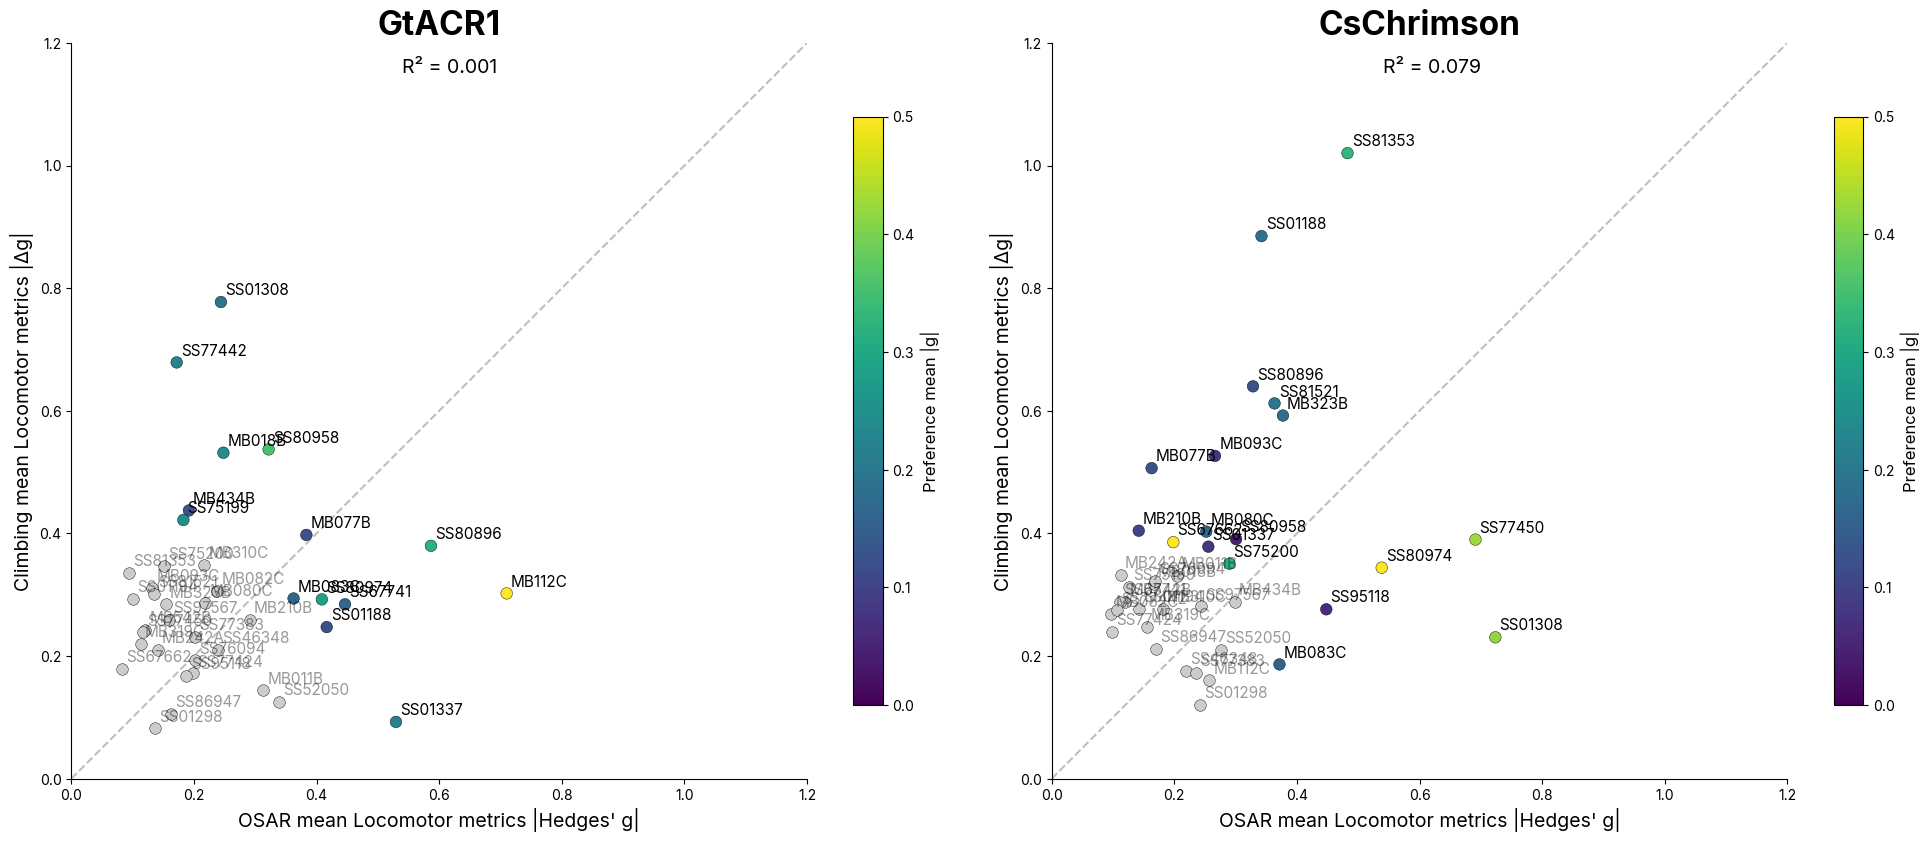

In [21]:
mpl.rcParams['svg.fonttype'] = 'none'

panels = [
    (osar_acr, climb_acr, pref_acr_t, high_acr, 'GtACR1'),
    (osar_chr, climb_chr, pref_chr_t, high_chr, 'CsChrimson'),
]

USE_MBON_NUMBERS = False
label_map_t = dict(zip(mbons_t, rename_labels(mbons_t, USE_MBON_NUMBERS)))

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

for ax, (x, y, c_val, mask, title), label in zip(axes, panels, ['A', 'B']):
    ax.scatter(x[~mask], y[~mask], s=70, color='#CCCCCC', zorder=2, edgecolors='k', linewidth=0.3)
    sc = ax.scatter(x[mask], y[mask], s=70, c=c_val[mask], cmap='viridis', zorder=3, edgecolors='k', vmin = 0, vmax = 0.5, linewidth=0.3)
    #sc = ax.scatter(x[mask], y[mask], s=40, c="#1960E6", zorder=3, edgecolors='k', linewidth=0.3)
    cbar = plt.colorbar(sc, ax=ax, label='Preference mean |g|',  shrink=0.8)
    cbar.set_label('Preference mean |g|', fontsize=12)

    for mbon in mbons_t:
        ax.annotate(label_map_t[mbon], (x[mbon], y[mbon]), fontsize=11, ha='left', va='bottom', xytext=(3, 3),
                    textcoords='offset points', alpha=1.0 if mask[mbon] else 0.4)

    ax.set_xlim(0, 1.2)
    ax.set_ylim(0, 1.2)
    ax.plot([0, 5], [0, 5], '--', color='gray', alpha=0.5, zorder=1)

    r_squared = stats.pearsonr(x, y)[0] ** 2
    ax.text(0.45, 0.96, f'R\u00b2 = {r_squared:.3f}', transform=ax.transAxes, fontsize=14)

    ax.set_xlabel("OSAR mean Locomotor metrics |Hedges' g|", fontsize=14)
    ax.set_ylabel('Climbing mean Locomotor metrics |\u0394g|', fontsize=14)
    ax.set_title(f'{title}', fontsize=24, fontweight='bold', loc='center')
    ax.set_aspect('equal')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
mpl.rcParams['svg.fonttype'] = 'none'
plt.savefig(specifiedpath + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\osar_compiled\\images\\" + date + "climbingvsosar.svg", bbox_inches="tight")
plt.show()

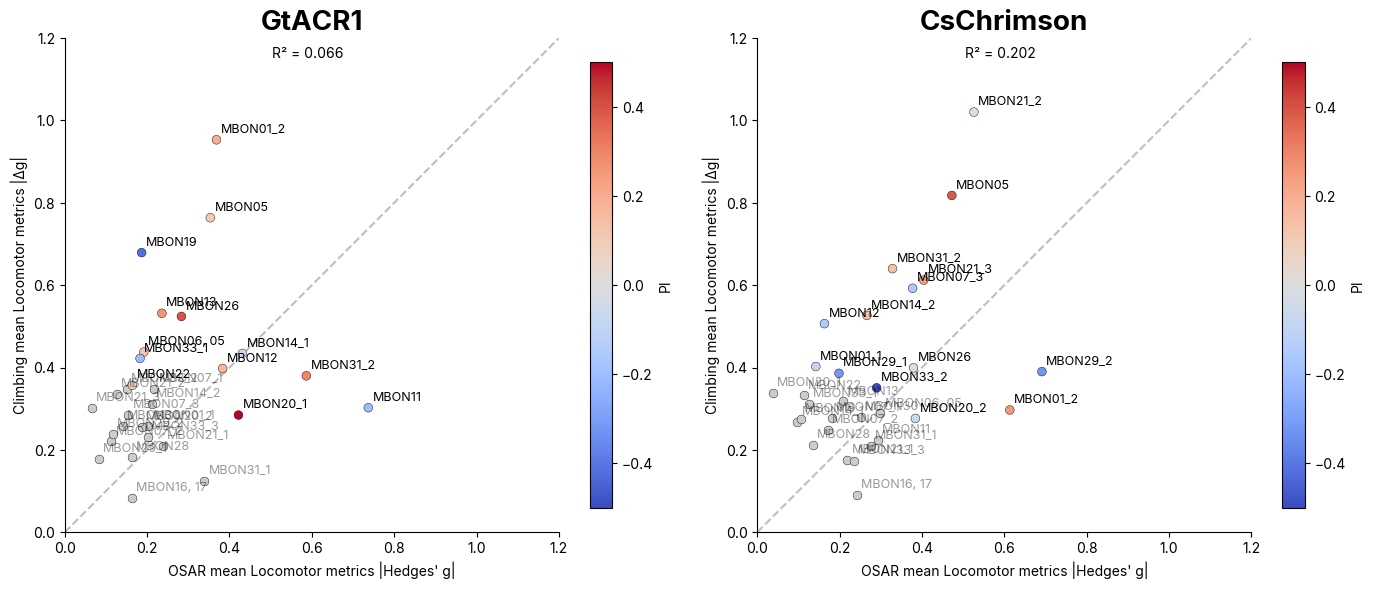

In [49]:
mpl.rcParams['svg.fonttype'] = 'none'

# Choose: 'PI_Hg_OSAR' or 'Light Attraction Index_Hg_OSAR'
color_metric = 'PI_Hg_OSAR'
color_label = 'PI' if color_metric == 'PI_Hg_OSAR' else 'LAI'

color_acr = acr_t[color_metric]
color_chr = chr_t[color_metric]

panels = [
    (osar_acr, climb_acr, color_acr, high_acr, 'GtACR1'),
    (osar_chr, climb_chr, color_chr, high_chr, 'CsChrimson'),
]

USE_MBON_NUMBERS = True
label_map_t = dict(zip(mbons_t, rename_labels(mbons_t, USE_MBON_NUMBERS)))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (x, y, c_val, mask, title), label in zip(axes, panels, ['A', 'B']):
    ax.scatter(x[~mask], y[~mask], s=40, color='#CCCCCC', zorder=2, edgecolors='k', linewidth=0.3)
    sc = ax.scatter(x[mask], y[mask], s=40, c=c_val[mask], cmap='coolwarm', zorder=3, edgecolors='k', vmin=-0.5, vmax=0.5, linewidth=0.3)
    plt.colorbar(sc, ax=ax, label=color_label, shrink=0.8)

    for mbon in mbons_t:
        ax.annotate(label_map_t[mbon], (x[mbon], y[mbon]), fontsize=9, ha='left', va='bottom', xytext=(3, 3),
                    textcoords='offset points', alpha=1.0 if mask[mbon] else 0.4)

    ax.set_xlim(0, 1.2)
    ax.set_ylim(0, 1.2)
    ax.plot([0, 5], [0, 5], '--', color='gray', alpha=0.5, zorder=1)

    r_squared = stats.pearsonr(x, y)[0] ** 2
    ax.text(0.42, 0.96, f'R\u00b2 = {r_squared:.3f}', transform=ax.transAxes, fontsize=10)

    ax.set_xlabel("OSAR mean Locomotor metrics |Hedges' g|", fontsize=10)
    ax.set_ylabel('Climbing mean Locomotor metrics |\u0394g|', fontsize=10)
    ax.set_title(f'{title}', fontsize=20, fontweight='bold', loc='center')
    ax.set_aspect('equal')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
mpl.rcParams['svg.fonttype'] = 'none'
plt.show()

In [ ]:
mpl.rcParams['svg.fonttype'] = 'none'
fig, ax = plt.subplots(figsize=(8, 8))

high_combined = high_acr & high_chr
pref_combined = (pref_acr_t + pref_chr_t) / 2

label_map_t = dict(zip(mbons_t, rename_labels(mbons_t, USE_MBON_NUMBERS)))

ax.scatter(combined_acr[~high_combined], combined_chr[~high_combined], s=40, color='#CCCCCC', zorder=2, edgecolors='k', linewidth=0.3)
sc = ax.scatter(combined_acr[high_combined], combined_chr[high_combined], s=40, c=pref_combined[high_combined], cmap='viridis', zorder=3, edgecolors='k', linewidth=0.3)
plt.colorbar(sc, ax=ax, label='Preference mean |g|', shrink=0.8)

for mbon in mbons_t:
    ax.annotate(label_map_t[mbon], (combined_acr[mbon], combined_chr[mbon]), fontsize=8, ha='left', va='bottom', xytext=(3, 3),
                textcoords='offset points', alpha=1.0 if high_combined[mbon] else 0.4)

lim = max(combined_acr.max(), combined_chr.max()) * 1.15
ax.plot([0, lim], [0, lim], '--', color='gray', alpha=0.5, zorder=1)
ax.set_xlim(0, lim)
ax.set_ylim(0, lim)

r_squared = stats.pearsonr(combined_acr, combined_chr)[0] ** 2
ax.text(0.05, 0.92, f'R\u00b2 = {r_squared:.3f}', transform=ax.transAxes, fontsize=10)

ax.set_xlabel('GtACR1 Combined mean |g|', fontsize=10)
ax.set_ylabel('CsChrimson Combined mean |g|', fontsize=10)
ax.set_title('Combined OSAR + Climbing Locomotor', fontsize=16, fontweight='bold', loc='left')
ax.set_aspect('equal')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

mpl.rcParams['svg.fonttype'] = 'none'

label_map_t = dict(zip(mbons_t, rename_labels(mbons_t, USE_MBON_NUMBERS)))

fig = plt.figure(figsize=(18, 7))

for col, (o, c, p, mask, title) in enumerate([
    (osar_acr, climb_acr, pref_acr_t, high_acr, 'GtACR1'),
    (osar_chr, climb_chr, pref_chr_t, high_chr, 'CsChrimson'),
]):
    ax = fig.add_subplot(1, 2, col + 1, projection='3d')
    ax.scatter(o[~mask], c[~mask], p[~mask], s=40, color='#CCCCCC', zorder=2)
    ax.scatter(o[mask], c[mask], p[mask], s=40, color="#5F5DFF", zorder=3)
    for mbon in mbons_t:
        ax.text(o[mbon], c[mbon], p[mbon], label_map_t[mbon], fontsize=7, alpha=1.0 if mask[mbon] else 0.3)
    ax.set_xlabel('OSAR Locomotor |g|', fontsize=9)
    ax.set_ylabel('Climbing Locomotor |g|', fontsize=9)
    ax.set_zlabel('OSAR Preference |g|', fontsize=9)
    ax.set_title(title, fontweight='bold', fontsize=14)

plt.tight_layout()
plt.show()

In [ ]:
mpl.rcParams['svg.fonttype'] = 'none'

panels = [
    (climb_acr, pref_acr_t, high_acr, 'GtACR1'),
    (climb_chr, pref_chr_t, high_chr, 'CsChrimson'),
]

label_map_t = dict(zip(mbons_t, rename_labels(mbons_t, USE_MBON_NUMBERS)))

fig, axes = plt.subplots(1, 2, figsize=(18, 5.5))

for ax, (x, y, mask, title), label in zip(axes, panels, ['A', 'B']):
    ax.scatter(x[~mask], y[~mask], s=40, color='#CCCCCC', zorder=2, edgecolors='k', linewidth=0.3)
    ax.scatter(x[mask], y[mask], s=40, color="#5F5DFF", zorder=3, edgecolors='k', linewidth=0.3)

    for mbon in mbons_t:
        ax.annotate(label_map_t[mbon], (x[mbon], y[mbon]), fontsize=8, ha='left', va='bottom', xytext=(3, 3),
                    textcoords='offset points', alpha=1.0 if mask[mbon] else 0.4)

    lim = max(x.max(), y.max()) * 1.15
    ax.plot([0, lim], [0, lim], '--', color='gray', alpha=0.5, zorder=1)
    ax.set_xlim(0, lim)
    ax.set_ylim(0, lim)

    r_squared = stats.pearsonr(x, y)[0] ** 2
    ax.text(0.05, 0.92, f'R\u00b2 = {r_squared:.3f}', transform=ax.transAxes, fontsize=10)

    ax.set_xlabel('Climbing Locomotor mean |g|', fontsize=10)
    ax.set_ylabel('Preference mean |g|', fontsize=10)
    ax.set_title(f'{label}. {title}', fontsize=16, fontweight='bold', loc='left')
    ax.set_aspect('equal')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()